In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path.cwd().resolve()
if (base / 'src').exists():
    ROOT = base
elif (base / 'research' / 'src').exists():
    ROOT = base / 'research'
elif (base.parent / 'src').exists():
    ROOT = base.parent
else:
    raise RuntimeError('Cannot locate research/src directory from current working directory')

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

plt.style.use('seaborn-v0_8-whitegrid')

from dynamics import anneal_bundle, CostConfig, rollout, bolza_cost

In [9]:
best_u_opt = pd.read_csv('best_u.csv', index_col='step').values

In [5]:
cfg = CostConfig()
eps = 0.1
rng = np.random.default_rng(28)
x0_base = np.zeros(6)
S = 50
initial_states = x0_base + rng.uniform(-eps, eps, size=(S, 6))

# Compute

In [12]:
best_u_bundle, best_j, trace = anneal_bundle(initial_states, best_u_opt, cfg, seed=28)

control_names = ['u1_roll', 'u2_pitch', 'u3_yaw', 'u4_thrust']

df_bundle = pd.DataFrame(best_u_bundle, columns=control_names)
df_bundle.index.name = 'step'

print(df_bundle.to_string())
print(f"J среднее по пучку = {best_j:.4f}")

df_bundle.to_csv('best_u_mean_bundle.csv')

df_states = pd.DataFrame(initial_states)
df_states.to_csv('initial_states_mean.csv')

       u1_roll  u2_pitch    u3_yaw  u4_thrust
step                                         
0    -0.166345  0.812450  0.016479  11.610442
1    -0.072453  0.036157  0.021203  11.871285
2    -0.115709 -0.221727 -0.094942  11.686896
3     0.047068 -0.128116  0.147258  11.699926
4    -0.163825 -0.181259  0.032995  11.631604
5     0.175260 -0.173089 -0.176761  10.542202
6     0.189284 -0.056801 -0.023613  11.967960
7    -0.119605 -0.239291  0.006394  11.896102
8     0.095577 -0.203857 -0.130612  11.582526
9    -0.108311  0.313587 -0.114089  11.639486
10    0.052988  0.583105 -0.188784  10.012446
11   -0.225483 -0.748004  0.048456   4.658729
12    0.261799  0.091088  0.088308  10.447348
13    0.159504  0.523216 -0.185739  11.935807
14   -0.201936 -0.967644 -0.192457   9.253314
J среднее по пучку = 6.1916


In [6]:
initial_states = pd.read_csv('initial_states_mean.csv', index_col=0).values
best_u_bundle = pd.read_csv('best_u_mean_bundle.csv', index_col='step').values

In [8]:
bundle_states = []
bundle_scores = []

for x0 in initial_states:
    X_k = rollout(x0, best_u_bundle, cfg.dt)
    score_k = bolza_cost(x0, best_u_bundle, cfg)
    bundle_states.append(X_k)
    bundle_scores.append(score_k)

bundle_states = np.array(bundle_states)   # (S, N+1, 6)
bundle_scores = np.array(bundle_scores)   # (S,)

# Visualization

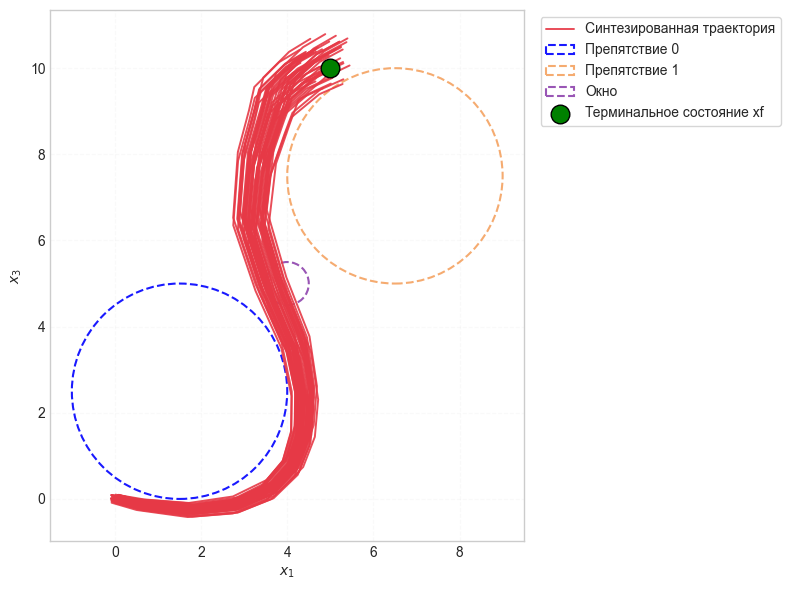

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for i, X_k in enumerate(bundle_states):
    ax.plot(
        X_k[:, 0], X_k[:, 2],
        color="#E63946",
        alpha=0.2,
        linewidth=1.4,
        label="Синтезированная траектория" if i == 0 else None
    )

for i, cyl in enumerate(cfg.cylinders):
    circle = plt.Circle(
        (cyl.x, cyl.z),
        cyl.radius,
        fill=False,
        linestyle="--",
        linewidth=1.5,
        edgecolor="#F4A261" if i == 1 else "blue",
        alpha=0.9,
        label=f"Препятствие {i}"
    )
    ax.add_patch(circle)

for i, wnd in enumerate(cfg.windows):
    circle = plt.Circle(
        (wnd.x, wnd.z),
        wnd.radius,
        fill=False,
        linestyle="--",
        linewidth=1.5,
        edgecolor="#8E44AD",
        alpha=0.9,
        label="Окно" if i == 0 else None
    )
    ax.add_patch(circle)

ax.scatter(
    [cfg.terminal_state[0]],
    [cfg.terminal_state[2]],
    marker="o",
    s=180,
    color="green",
    edgecolor="black",
    zorder=6,
    label="Терминальное состояние xf"
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_3$")
ax.set_aspect("equal", adjustable="box")

ax.grid(
    True,
    linestyle="--",
    alpha=0.1
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True
)

plt.tight_layout()
plt.show()

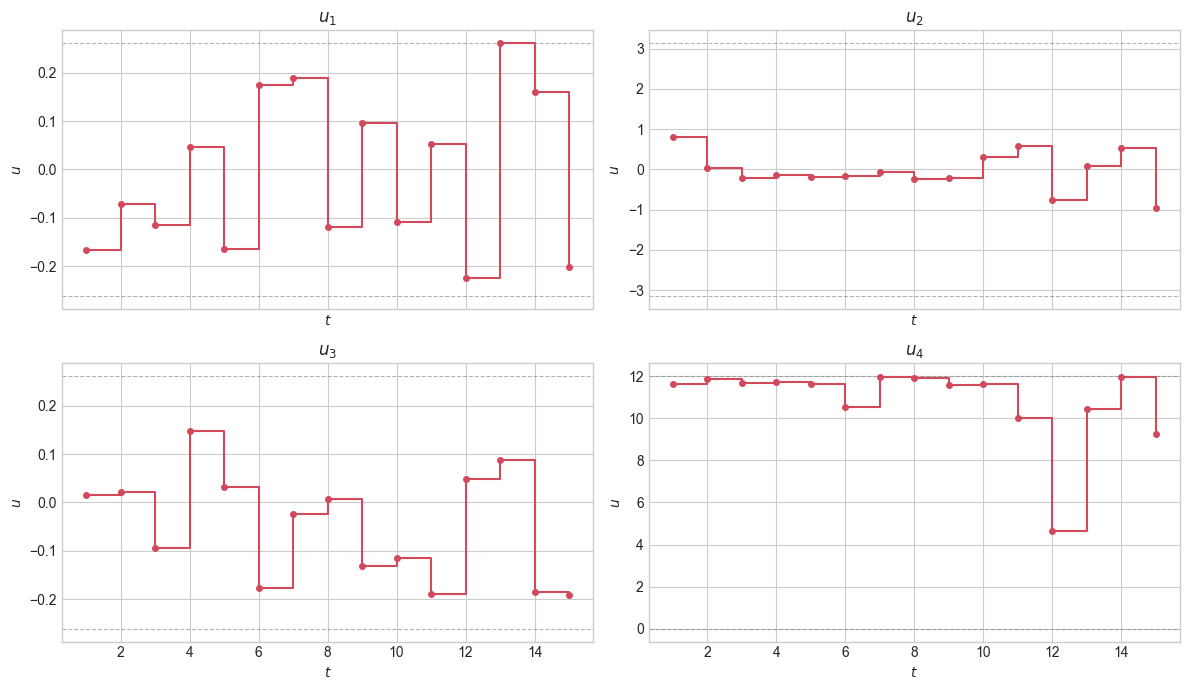

In [18]:
control_names  = ['$u_1$', '$u_2$', '$u_3$',  '$u_4$']
control_limits = [
    (-np.pi/12, np.pi/12),
    (-np.pi,    np.pi),
    (-np.pi/12, np.pi/12),
    (0.0,       12.0),
]

steps = np.arange(1, best_u_bundle.shape[0] + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

for j, ax in enumerate(axes.ravel()):
    lo, hi = control_limits[j]
    ax.axhline(lo, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.axhline(hi, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.step(steps, best_u_bundle[:, j], where='post', color='#D1495B', linewidth=1.5)
    ax.plot(steps, best_u_bundle[:, j], 'o', color='#D1495B', markersize=4)
    ax.set_title(control_names[j])
    ax.set_xlabel('$t$')
    ax.set_ylabel('$u$')

plt.tight_layout()
plt.show()